# Detección de plantas invasoras — Cundinamarca
Entrenamiento y evaluación de **RT-DETR** (formato YOLOv8) y **RF-DETR** (formato COCO).

Ejecuta las celdas en orden. Cada sección es independiente — puedes correr solo RT-DETR o solo RF-DETR.

**Clases (orden fijo):** `Acacia negra`, `Buchon de agua`, `Helecho de agua`, `Retamo espinoso`. El dataset trae además una clase `sin_invasion` (plantas NO invasoras) que se usa como **negativos**; cómo se tratan lo controla `MODO_NEGATIVOS` en la celda 1.

## 0 · Instalación de dependencias

In [23]:
# Si ya estás usando el kernel "Python 3.12 (ROCm — RX 9060 XT)", todo está instalado.
# Esta celda solo es necesaria para un entorno limpio.
# %pip install -q ultralytics
# %pip install -q "rfdetr[train,loggers]"
print("Si usas el kernel ROCm, salta esta celda.")

Si usas el kernel ROCm, salta esta celda.


## 1 · Verificar GPU

In [1]:
import torch
from pathlib import Path

# ──────────────────────────── Configuración ────────────────────────────
# Cómo tratar las imágenes "sin_invasion" (plantas NO invasoras):
#   "fondo" → negativos SIN etiqueta (nc=4). [Recomendado] reduce falsos positivos.
#   "clase" → sin_invasion se mantiene como 5ª clase de detección (nc=5).
MODO_NEGATIVOS = "fondo"
# Tope de proporción de negativos en el dataset final (evita hundir el recall).
# 0.20 = máximo 20% de imágenes negativas; usa 1.0 para conservarlos todos.
NEG_RATIO_MAX = 0.20

ROOT        = Path.cwd()
# Exports pristinos de Roboflow — NO se modifican
SRC_COCO    = ROOT / "NuevasPlantas2.coco"
SRC_YOLO    = ROOT / "NuevasPlantas2.yolov8"
# Datasets derivados que construye la celda 2 (train/valid con split compartido)
RFDETR_DATA = ROOT / "data_rfdetr"        # COCO → RF-DETR
RTDETR_DATA = ROOT / "data_rtdetr"        # YOLO → RT-DETR
RTDETR_YAML = RTDETR_DATA / "data.yaml"
MANIFEST    = ROOT / "split_manifest.json"
RUNS_DIR    = ROOT / "runs"
RTDETR_RUN  = RUNS_DIR / "rtdetr" / "plantas_invasoras"
RFDETR_RUN  = RUNS_DIR / "rfdetr" / "plantas_invasoras"

# Que ultralytics resuelva `path:` del data.yaml respecto a la carpeta del proyecto
try:
    from ultralytics import settings as _ul_settings
    _ul_settings.update({"datasets_dir": str(ROOT)})
except Exception as _e:
    print(f"(aviso) no se pudo actualizar datasets_dir de ultralytics: {_e}")

# Detección automática de GPU (CUDA NVIDIA o ROCm AMD — la API es la misma)
if torch.cuda.is_available():
    DEVICE   = 0
    GPU_NAME = torch.cuda.get_device_name(0)
    print(f"GPU detectada: {GPU_NAME}  →  entrenando en device={DEVICE}")
else:
    DEVICE   = "cpu"
    GPU_NAME = None
    print("GPU no detectada — entrenando en CPU")
    print("  · Si tienes una Radeon RX 7000/9000 o Ryzen AI 300/MAX, instala PyTorch ROCm (ver SETUP.md).")

print(f"\nMODO_NEGATIVOS: {MODO_NEGATIVOS}  |  NEG_RATIO_MAX: {NEG_RATIO_MAX}")
print(f"ROOT: {ROOT}")
print(f"SRC_COCO existe:  {SRC_COCO.exists()}")
print(f"SRC_YOLO existe:  {SRC_YOLO.exists()}")

GPU detectada: AMD Radeon RX 9060 XT  →  entrenando en device=0

MODO_NEGATIVOS: fondo  |  NEG_RATIO_MAX: 0.2
ROOT: c:\Users\palep\OneDrive\Documentos\im y vi
SRC_COCO existe:  True
SRC_YOLO existe:  True


## 2 · Preparar datasets
Construye los datasets **derivados** `data_rfdetr/` (COCO → RF-DETR) y `data_rtdetr/` (YOLO → RT-DETR) a partir de los exports pristinos, con:
- **split de validación compartido** — las mismas imágenes van a `valid/` en ambos formatos (comparación justa entre modelos),
- manejo de negativos según `MODO_NEGATIVOS` y tope `NEG_RATIO_MAX`,
- `split_manifest.json` reproducible — para que el YOLO del compañero use **exactamente el mismo split**.

Los exports `NuevasPlantas2.*` **no se modifican**; reejecutar esta celda reconstruye todo (idempotente).

In [2]:
"""
Preparación de datasets — plantas invasoras Cundinamarca

Construye datasets DERIVADOS (train/valid) para RT-DETR (YOLO) y RF-DETR (COCO)
a partir de los exports pristinos de Roboflow. Aporta:

  - Split de validación COMPARTIDO: las mismas imágenes van a valid/ en ambos
    formatos (clave = nombre de archivo, idéntico entre el export COCO y el YOLO).
  - Manejo de negativos (clase `sin_invasion`) según MODO_NEGATIVOS:
        "fondo" → se quitan sus cajas; la imagen queda como negativo sin etiqueta.
        "clase" → se mantiene como 5ª clase de detección.
  - Tope de proporción de negativos (NEG_RATIO_MAX) para no pasarse y hundir el recall.
  - Manifiesto reproducible `split_manifest.json` para que el YOLO del compañero
    use EXACTAMENTE el mismo split (comparación justa entre los 3 modelos).

Los exports originales NO se modifican: todo se construye en carpetas derivadas,
así que reejecutar es idempotente y cambiar de modo no exige re-exportar de Roboflow.
"""

import json, shutil, random
from pathlib import Path

CLASES_INVASORAS = ["Acacia negra", "Buchon de agua", "Helecho de agua", "Retamo espinoso"]
CLASE_NEGATIVA   = "sin_invasion"
IDX_NEG_YOLO     = 4    # índice de sin_invasion en los .txt YOLO
CAT_NEG_COCO     = 5    # category_id de sin_invasion en el JSON COCO
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def _clave(nombre_archivo: str) -> str:
    """Identidad estable de la imagen, común a COCO y YOLO (nombre sin extensión)."""
    return Path(nombre_archivo).stem


# ──────────────────────── Leer origen + clasificar ────────────────────────

def _cargar_origen_coco(src_coco: Path):
    """Devuelve {clave: {'file_name', 'tipo'}}. tipo='positivo' si la imagen tiene
    alguna invasora; 'negativo' si solo tiene sin_invasion o ninguna anotación."""
    cats_por_clave, file_por_clave = {}, {}
    for split in ("train", "valid", "test"):
        p = src_coco / split / "_annotations.coco.json"
        if not p.exists():
            continue
        coco = json.load(open(p))
        id2fn = {img["id"]: img["file_name"] for img in coco["images"]}
        for img in coco["images"]:
            k = _clave(img["file_name"])
            file_por_clave.setdefault(k, img["file_name"])
            cats_por_clave.setdefault(k, set())
        for a in coco["annotations"]:
            fn = id2fn.get(a["image_id"])
            if fn:
                cats_por_clave[_clave(fn)].add(int(a["category_id"]))
    info = {}
    for k, cats in cats_por_clave.items():
        invasoras = cats - {CAT_NEG_COCO}
        info[k] = {"file_name": file_por_clave[k],
                   "tipo": "positivo" if invasoras else "negativo"}
    return info


def _decidir_split(info, neg_ratio_max, val_ratio, seed):
    """Aplica el tope de negativos y reparte en train/valid de forma estratificada.
    Devuelve (asignacion {clave: 'train'|'valid'}, negativos_descartados set)."""
    pos = sorted(k for k, v in info.items() if v["tipo"] == "positivo")
    neg = sorted(k for k, v in info.items() if v["tipo"] == "negativo")
    rng = random.Random(seed)
    rng.shuffle(pos)
    rng.shuffle(neg)

    if neg_ratio_max is not None and neg_ratio_max < 1.0 and pos:
        n_max = int(len(pos) * neg_ratio_max / (1 - neg_ratio_max))
        neg_keep = neg[:n_max]
    else:
        neg_keep = neg
    neg_drop = set(neg) - set(neg_keep)

    def particion(keys):
        if not keys:
            return set(), set()
        n_val = max(1, round(len(keys) * val_ratio))
        return set(keys[:n_val]), set(keys[n_val:])  # (valid, train)

    val_pos, train_pos = particion(pos)
    val_neg, train_neg = particion(neg_keep)

    asignacion = {}
    for k in train_pos | train_neg:
        asignacion[k] = "train"
    for k in val_pos | val_neg:
        asignacion[k] = "valid"
    return asignacion, neg_drop


# ──────────────────────── Construir COCO (RF-DETR) ────────────────────────

def _merge_coco(src_coco: Path):
    """Une todos los splits de origen en pools únicos (ids reasignados, bbox a float)."""
    images, annotations, categories = [], [], None
    next_img, next_ann, vistas = 1, 1, set()
    for split in ("train", "valid", "test"):
        p = src_coco / split / "_annotations.coco.json"
        if not p.exists():
            continue
        coco = json.load(open(p))
        if categories is None:
            categories = coco["categories"]
        old2new = {}
        for img in coco["images"]:
            k = _clave(img["file_name"])
            if k in vistas:
                old2new[img["id"]] = None
                continue
            vistas.add(k)
            old2new[img["id"]] = next_img
            ni = dict(img); ni["id"] = next_img; ni["_clave"] = k
            images.append(ni); next_img += 1
        for a in coco["annotations"]:
            nid = old2new.get(a["image_id"])
            if nid is None:
                continue
            na = dict(a); na["id"] = next_ann; na["image_id"] = nid
            na["bbox"] = [float(v) for v in na["bbox"]]   # fix bug Roboflow
            annotations.append(na); next_ann += 1
    return images, annotations, (categories or [])


def _mapa_imgs(src_coco: Path):
    m = {}
    for split in ("train", "valid", "test"):
        d = src_coco / split
        if d.exists():
            for p in d.iterdir():
                if p.suffix.lower() in IMG_EXTS:
                    m[p.name] = p
    return m


def _construir_coco(src_coco: Path, out_coco: Path, asignacion, modo):
    if out_coco.exists():
        shutil.rmtree(out_coco)
    images, annotations, categories = _merge_coco(src_coco)
    if modo == "fondo":
        categories  = [c for c in categories if c["id"] != CAT_NEG_COCO]
        annotations = [a for a in annotations if a["category_id"] != CAT_NEG_COCO]
    mapa = _mapa_imgs(src_coco)

    for split in ("train", "valid"):
        imgs = [im for im in images if asignacion.get(im["_clave"]) == split]
        ids  = {im["id"] for im in imgs}
        anns = [a for a in annotations if a["image_id"] in ids]
        dest = out_coco / split
        dest.mkdir(parents=True, exist_ok=True)
        for im in imgs:
            src = mapa.get(im["file_name"])
            if src:
                shutil.copy2(src, dest / im["file_name"])
        limpias = [{k: v for k, v in im.items() if k != "_clave"} for im in imgs]
        json.dump({"images": limpias, "annotations": anns, "categories": categories},
                  open(dest / "_annotations.coco.json", "w"))


# ──────────────────────── Construir YOLO (RT-DETR) ────────────────────────

def _escribir_data_yaml(yaml_path: Path, dirname: str, modo: str):
    names = CLASES_INVASORAS + ([CLASE_NEGATIVA] if modo == "clase" else [])
    val_target = "valid/images" if (yaml_path.parent / "valid" / "images").exists() else "train/images"
    yaml_path.write_text(
        f"path: {dirname}\ntrain: train/images\nval: {val_target}\n\n"
        f"nc: {len(names)}\nnames:\n" + "".join(f"  - {n}\n" for n in names)
    )


def _construir_yolo(src_yolo: Path, out_yolo: Path, asignacion, modo):
    if out_yolo.exists():
        shutil.rmtree(out_yolo)
    for split_src in ("train", "valid", "test"):
        img_dir = src_yolo / split_src / "images"
        lbl_dir = src_yolo / split_src / "labels"
        if not img_dir.exists():
            continue
        for img in img_dir.iterdir():
            if img.suffix.lower() not in IMG_EXTS:
                continue
            destino = asignacion.get(img.stem)
            if destino is None:          # negativo descartado por el tope
                continue
            di = out_yolo / destino / "images"
            dl = out_yolo / destino / "labels"
            di.mkdir(parents=True, exist_ok=True)
            dl.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img, di / img.name)
            src_lbl = lbl_dir / (img.stem + ".txt")
            lineas = [l for l in src_lbl.read_text().splitlines() if l.strip()] if src_lbl.exists() else []
            if modo == "fondo":
                lineas = [l for l in lineas if int(l.split()[0]) != IDX_NEG_YOLO]
            (dl / (img.stem + ".txt")).write_text(("\n".join(lineas) + "\n") if lineas else "")
    _escribir_data_yaml(out_yolo / "data.yaml", out_yolo.name, modo)


# ──────────────────────── Manifiesto ────────────────────────

def _escribir_manifest(path: Path, info, asignacion, neg_drop, modo, neg_ratio_max, val_ratio, seed):
    imagenes = {}
    for k, v in info.items():
        estado = "descartada" if k in neg_drop else asignacion.get(k, "?")
        imagenes[k] = {"file_name": v["file_name"], "tipo": v["tipo"], "split": estado}
    resumen = {
        "modo_negativos": modo, "neg_ratio_max": neg_ratio_max,
        "val_ratio": val_ratio, "seed": seed,
        "n_total": len(info),
        "n_positivos": sum(1 for v in info.values() if v["tipo"] == "positivo"),
        "n_negativos": sum(1 for v in info.values() if v["tipo"] == "negativo"),
        "n_negativos_descartados": len(neg_drop),
        "n_train": sum(1 for a in asignacion.values() if a == "train"),
        "n_valid": sum(1 for a in asignacion.values() if a == "valid"),
    }
    json.dump({"resumen": resumen, "imagenes": imagenes},
              open(path, "w"), indent=2, ensure_ascii=False)
    return resumen


# ──────────────────────── Entrada principal ────────────────────────

def preparar(src_coco, src_yolo, out_coco, out_yolo, manifest_path,
             modo="fondo", neg_ratio_max=0.30, val_ratio=0.2, seed=42, verbose=True):
    """Construye los datasets derivados con split compartido. Devuelve el resumen."""
    src_coco, src_yolo = Path(src_coco), Path(src_yolo)
    out_coco, out_yolo = Path(out_coco), Path(out_yolo)
    assert src_coco.exists(), f"No existe {src_coco}. Revisa SETUP.md."
    assert src_yolo.exists(), f"No existe {src_yolo}. Revisa SETUP.md."

    info = _cargar_origen_coco(src_coco)
    asignacion, neg_drop = _decidir_split(info, neg_ratio_max, val_ratio, seed)
    _construir_coco(src_coco, out_coco, asignacion, modo)
    _construir_yolo(src_yolo, out_yolo, asignacion, modo)
    resumen = _escribir_manifest(Path(manifest_path), info, asignacion, neg_drop,
                                 modo, neg_ratio_max, val_ratio, seed)

    if verbose:
        r = resumen
        print(f"Modo negativos: {modo}  |  tope negativos: {neg_ratio_max}")
        print(f"  Positivos: {r['n_positivos']}  |  Negativos: {r['n_negativos']} "
              f"(descartados por tope: {r['n_negativos_descartados']})")
        print(f"  Split compartido → train: {r['n_train']}  |  valid: {r['n_valid']}")
        usados = r['n_train'] + r['n_valid']
        neg_usados = r['n_negativos'] - r['n_negativos_descartados']
        print(f"  Proporción de negativos final: {neg_usados}/{usados} = {neg_usados/usados:.0%}")
        print(f"  COCO  → {out_coco}")
        print(f"  YOLO  → {out_yolo}")
        print(f"  Manifiesto → {manifest_path}")
    return resumen


# ──────────────────────────── Ejecutar ────────────────────────────
preparar(
    src_coco=SRC_COCO, src_yolo=SRC_YOLO,
    out_coco=RFDETR_DATA, out_yolo=RTDETR_DATA,
    manifest_path=MANIFEST,
    modo=MODO_NEGATIVOS, neg_ratio_max=NEG_RATIO_MAX,
)

Modo negativos: fondo  |  tope negativos: 0.2
  Positivos: 195  |  Negativos: 142 (descartados por tope: 94)
  Split compartido → train: 194  |  valid: 49
  Proporción de negativos final: 48/243 = 20%
  COCO  → c:\Users\palep\OneDrive\Documentos\im y vi\data_rfdetr
  YOLO  → c:\Users\palep\OneDrive\Documentos\im y vi\data_rtdetr
  Manifiesto → c:\Users\palep\OneDrive\Documentos\im y vi\split_manifest.json


{'modo_negativos': 'fondo',
 'neg_ratio_max': 0.2,
 'val_ratio': 0.2,
 'seed': 42,
 'n_total': 337,
 'n_positivos': 195,
 'n_negativos': 142,
 'n_negativos_descartados': 94,
 'n_train': 194,
 'n_valid': 49}

## 3 · Entrenamiento RT-DETR
Modelo transformer de Baidu. Usa el dataset en formato **YOLOv8**.

> Tarda varios minutos por época en CPU.

In [26]:
import os
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

import gc, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM libre antes de entrenar: {free/1024**3:.2f} / {total/1024**3:.2f} GiB")

from ultralytics import RTDETR

assert RTDETR_YAML.exists(), f"No existe {RTDETR_YAML}. Ejecuta la celda 2 (Preparar datasets)."

# rtdetr-l (más liviano que rtdetr-x) para evitar OOM en 16 GiB de VRAM
model_rtdetr = RTDETR("rtdetr-l.pt")

results_rtdetr = model_rtdetr.train(
    data=str(RTDETR_YAML),
    epochs=100,
    imgsz=640,
    batch=8,
    device=DEVICE,
    workers=0,
    cache=False,
    freeze=1,
    lr0=1e-4,
    lrf=0.01,
    warmup_epochs=3,
    patience=30,
    save=True,
    project=str(RUNS_DIR / "rtdetr"),
    name="plantas_invasoras",
    exist_ok=True,
    verbose=True,
    amp=True,
)

print("\n--- Entrenamiento RT-DETR finalizado ---")
print(f"Mejor modelo: {RTDETR_RUN / 'weights' / 'best.pt'}")

VRAM libre antes de entrenar: 11.87 / 15.92 GiB
New https://pypi.org/project/ultralytics/8.4.52 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.12.0 torch-2.9.1+rocm7.2.1 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\palep\OneDrive\Documentos\im y vi\data_rtdetr\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=1, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, m

2026/05/21 02:45:45 INFO mlflow.tracking.fluent: Autologging successfully enabled for pytorch_lightning.
2026/05/21 02:45:45 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/21 02:45:45 INFO mlflow.tracking.fluent: Autologging successfully enabled for transformers.


MLflow: logging run_id(e616294f1dfa439e844ca2e87bc24439) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\palep\OneDrive\Documentos\im y vi\runs\rtdetr\plantas_invasoras
Starting training for 100 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      1/100      2.52G      1.351      195.3       1.21          3        640: 0% ──────────── 0/28  3:02

      1/100      2.69G      1.173      33.46      1.254          6        640: 100% ━━━━━━━━━━━━ 28/28 12.6s/it 5:54.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 11.8s/it 47.0s.3s34
                   all         56         39   0.000438      0.264   0.000613   0.000178

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


      2/100        10G     0.7404      1.718     0.8078          8        640: 100% ━━━━━━━━━━━━ 28/28 1.3s/it 35.0s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s1.2s
                   all         56         39   0.000109      0.159   0.000304    0.00013

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

     89/100      9.48G     0.3478     0.5629     0.3954         13        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 34.2s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.5s1.1s
                   all         56         39      0.345      0.267      0.282      0.107

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


     90/100      9.49G     0.3354     0.5807     0.3536          7        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 34.2s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s1.1s
                   all         56         39       0.31      0.373      0.284      0.115
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


     91/100      9.49G     0.3133     0.6012      0.498          5        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 33.9s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s1.1s
                   all         56         39      0.311      0.341      0.308      0.128

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


     92/100      9.49G     0.2772     0.5515     0.4129          4        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 34.2s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s1.2s
                   all         56         39      0.349      0.306       0.29      0.113

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


     93/100      9.47G     0.2601     0.5539     0.4103          4        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 34.1s1.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s1.1s
                   all         56         39      0.244      0.413      0.269      0.109
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 63, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

93 epochs completed in 1.083 hours.
Optimizer stripped from C:\Users\palep\OneDrive\Documentos\im y vi\runs\rtdetr\plantas_invasoras\weights\last.pt, 66.2MB
Optimizer stripped from C:\Users\palep\OneDrive\Documentos\im y vi\runs\rtdetr\plantas_invasoras\weights\best.pt, 66.2MB

Validating C:\Users\palep\OneDrive\Documentos\im y vi\runs\rtdetr\plantas_invasoras\weights\best.pt...

## 4 · Entrenamiento RF-DETR
Modelo de Roboflow basado en DINOv2. Usa el dataset en formato **COCO**.

> Tarda varios minutos por época en CPU.

In [27]:
from rfdetr import RFDETRBase

assert RFDETR_DATA.exists(), f"No existe {RFDETR_DATA}. Ejecuta la celda 2 (Preparar datasets)."

# Resolución 448 (múltiplo de 56) en vez de los 560 por defecto: menos VRAM.
model_rfdetr = RFDETRBase(resolution=448)

model_rfdetr.train(
    dataset_dir=str(RFDETR_DATA),
    epochs=100,
    # Carga reducida para evitar TDR del driver AMD (parpadeo + reset de GPU).
    # batch efectivo = batch_size * grad_accumulation_steps = 2 * 8 = 16
    batch_size=2,
    grad_accumulation_steps=8,
    lr=1e-4,
    num_workers=0,
    # Desactiva la EMA: si la GPU hace un glitch y mete NaN/Inf, evita el
    # OverflowError en el cálculo de decay (math.exp) que rompe el run.
    use_ema=False,
    # Precisión mixta — menos VRAM y menos presión térmica/driver.
    amp=True,
    output_dir=str(RFDETR_RUN),
)

print("\n--- Entrenamiento RF-DETR finalizado ---")
print(f"Modelo guardado en: {RFDETR_RUN}")

[2026-05-21 03:50:55] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-21 03:50:56] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-21 03:50:58] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-05-21 03:50:58] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 5. The detection head will be re-initialized to 5 classes.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026/05/21 03:50:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1176155618004c9ea44443ca5dc3105b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current pytorch workflow


[2026-05-21 03:50:58] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 448
[2026-05-21 03:50:58] [INFO] rf-detr - Using multi-scale training with square resize and scales: [728]
[2026-05-21 03:50:58] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-05-21 03:50:58] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[2026-05-21 03:50:58] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 448
[2026-05-21 03:50:58] [INFO] rf-detr - Using multi-scale training with square resize and scales: [728]
[2026-05-21 03:50:58] [INFO] rf-detr - Built 1 Albumentations transforms from config


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


...

                       Val — Per-class Metrics                       
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class           ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Acacia negra    │   0.1397 │ 0.6000 │ 0.8000 │    0.8000 │ 0.8000 │
│ Buchon de agua  │   0.2025 │ 0.4333 │ 0.4444 │    0.5000 │ 0.4000 │
│ Helecho de agua │   0.1662 │ 0.6455 │ 0.6316 │    0.7500 │ 0.5455 │
│ Retamo espinoso │   0.1420 │ 0.5625 │ 0.3333 │    0.5000 │ 0.2500 │
└─────────────────┴──────────┴────────┴────────┴───────────┴────────┘

2026/05/21 04:57:56 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored metric value is not available.
`Trainer.fit` stopped: `max_epochs=100` reached.


[2026-05-21 04:57:58] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.2712, ema=0.0000)


2026/05/21 04:57:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/21 04:57:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+rocm7.2.1) contains a local version label (+rocm7.2.1). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



--- Entrenamiento RF-DETR finalizado ---
Modelo guardado en: c:\Users\palep\OneDrive\Documentos\im y vi\runs\rfdetr\plantas_invasoras


## 5 — Evaluación y comparación
Evaluación **unificada**: ambos modelos se miden con el mismo motor (`supervision`) sobre el **mismo set de validación** (el split es compartido), para que las métricas por clase sean directamente comparables. Produce: **(1)** métricas globales (mAP@50, mAP@75, mAP@[.5:.95], AR@100, precisión, recall, F1, velocidad ms/img y FPS), **(2)** métricas **por clase** (AP, precisión, recall, F1) y **(3)** la **matriz de confusión** de cada modelo. P/R/F1 y la matriz se reportan a `conf>=0.50`, IoU 0.50.

In [3]:
import json, time
from collections import defaultdict
import numpy as np
from PIL import Image
import supervision as sv
from supervision.metrics import (MeanAveragePrecision, MeanAverageRecall,
                                 Precision, Recall, MetricTarget, AveragingMethod)

# ----------------------------------------------------------------------------
# Evaluación UNIFICADA: ambos modelos se evalúan con el mismo motor (supervision)
# sobre el MISMO set de validación (el split es compartido), así las métricas
# por clase son directamente comparables. Para un paper esto es lo correcto:
# un solo evaluador y un solo conjunto de prueba.
# ----------------------------------------------------------------------------
CLASES_ORDEN = ["Acacia negra", "Buchon de agua", "Helecho de agua", "Retamo espinoso"]
CONF_MIN = 0.05   # umbral bajo: predicciones usadas para mAP / AR (curva PR completa)
CONF_OP  = 0.50   # punto de operación: P / R / F1 y matriz de confusión (IoU 0.50)

RTDETR_WEIGHTS = RTDETR_RUN / "weights" / "best.pt"
RF_CKPT        = RFDETR_RUN / "checkpoint_best_regular.pth"
COCO_VALID     = RFDETR_DATA / "valid" / "_annotations.coco.json"

# ---------- Ground truth (COCO del set de validación) ----------
name2idx = {n: i for i, n in enumerate(CLASES_ORDEN)}
coco = json.load(open(COCO_VALID, encoding="utf-8"))
catid2idx = {c["id"]: name2idx[c["name"]] for c in coco["categories"] if c["name"] in name2idx}
gt_boxes, gt_cls = defaultdict(list), defaultdict(list)
for a in coco["annotations"]:
    if a["category_id"] not in catid2idx:
        continue                                  # ignora "Object-Detection" / "sin_invasion"
    x, y, w, h = (float(v) for v in a["bbox"])     # bbox COCO viene como string -> float
    gt_boxes[a["image_id"]].append([x, y, x + w, y + h])
    gt_cls[a["image_id"]].append(catid2idx[a["category_id"]])

img_paths, targets = [], []
for im in coco["images"]:
    iid = im["id"]
    img_paths.append(RFDETR_DATA / "valid" / im["file_name"])
    if gt_boxes[iid]:
        targets.append(sv.Detections(xyxy=np.array(gt_boxes[iid], dtype=float),
                                     class_id=np.array(gt_cls[iid], dtype=int)))
    else:
        targets.append(sv.Detections.empty())
print(f"Set de validación: {len(img_paths)} imágenes, "
      f"{sum(len(t) for t in targets)} objetos.")

# ---------- Inferencia por modelo ----------
def _empty():
    d = sv.Detections.empty(); d.confidence = np.array([]); return d

def predecir_rtdetr():
    from ultralytics import RTDETR
    if not RTDETR_WEIGHTS.exists():
        print(f"RT-DETR: no se encontró {RTDETR_WEIGHTS}"); return None, None
    m = RTDETR(str(RTDETR_WEIGHTS))
    m.predict(str(img_paths[0]), conf=CONF_MIN, verbose=False)   # warmup (compila kernels)
    preds, t = [], 0.0
    for p in img_paths:
        t0 = time.perf_counter()
        res = m.predict(str(p), conf=CONF_MIN, verbose=False)[0]
        t += time.perf_counter() - t0
        preds.append(sv.Detections.from_ultralytics(res))         # class_id ya es 0..3
    ms = 1000 * t / len(img_paths)
    del m
    try:
        import torch; torch.cuda.empty_cache()
    except Exception:
        pass
    return preds, ms

def predecir_rfdetr():
    if not RF_CKPT.exists():
        print(f"RF-DETR: no se encontró {RF_CKPT}"); return None, None
    from rfdetr import RFDETRBase
    model = RFDETRBase(pretrain_weights=str(RF_CKPT), num_classes=5, resolution=448)
    imgs = [Image.open(p).convert("RGB") for p in img_paths]
    model.predict(imgs[0], threshold=CONF_MIN)                    # warmup
    preds, t = [], 0.0
    for img in imgs:
        t0 = time.perf_counter()
        det = model.predict(img, threshold=CONF_MIN)
        t += time.perf_counter() - t0
        keep = np.isin(det.class_id, list(catid2idx.keys()))      # solo las 4 invasoras
        d = sv.Detections(xyxy=det.xyxy[keep],
                          class_id=np.array([catid2idx[int(c)] for c in det.class_id[keep]], dtype=int))
        d.confidence = det.confidence[keep]
        preds.append(d if len(d) else _empty())
    ms = 1000 * t / len(img_paths)
    del model
    try:
        import torch; torch.cuda.empty_cache()
    except Exception:
        pass
    return preds, ms

# ---------- Métricas para un conjunto de predicciones ----------
def _por_clase(matched, valores):
    return {int(c): float(v) for c, v in zip(matched, valores)}

def evaluar(preds, ms_img):
    # mAP / AR usan TODAS las predicciones (conf >= CONF_MIN)
    mapr = MeanAveragePrecision(metric_target=MetricTarget.BOXES).update(preds, targets).compute()
    mar  = MeanAverageRecall(metric_target=MetricTarget.BOXES).update(preds, targets).compute()
    ap_pc = _por_clase(mapr.matched_classes, np.asarray(mapr.ap_per_class).mean(axis=1))
    # P / R / F1 en el punto de operación (conf >= CONF_OP), IoU 0.50
    op = []
    for d in preds:
        if len(d) and d.confidence is not None:
            m = d.confidence >= CONF_OP
            dd = sv.Detections(xyxy=d.xyxy[m], class_id=d.class_id[m]); dd.confidence = d.confidence[m]
            op.append(dd if len(dd) else _empty())
        else:
            op.append(_empty())
    P = Precision(metric_target=MetricTarget.BOXES, averaging_method=AveragingMethod.MACRO).update(op, targets).compute()
    R = Recall(metric_target=MetricTarget.BOXES, averaging_method=AveragingMethod.MACRO).update(op, targets).compute()
    p_pc = _por_clase(P.matched_classes, np.asarray(P.precision_per_class)[:, 0])
    r_pc = _por_clase(R.matched_classes, np.asarray(R.recall_per_class)[:, 0])
    p, r = float(P.precision_at_50), float(R.recall_at_50)
    f1 = (2 * p * r / (p + r)) if (p + r) else 0.0
    cm = sv.ConfusionMatrix.from_detections(predictions=op, targets=targets, classes=CLASES_ORDEN)
    return {
        "global": {"mAP50": mapr.map50, "mAP75": mapr.map75, "mAP50-95": mapr.map50_95,
                   "AR@100": mar.mAR_at_100, "Precisión": p, "Recall": r, "F1": f1,
                   "ms/img": ms_img, "FPS": 1000 / ms_img if ms_img else 0.0},
        "clase": {c: {"AP50-95": ap_pc.get(i, float("nan")),
                      "Precisión": p_pc.get(i, float("nan")),
                      "Recall":    r_pc.get(i, float("nan")),
                      "F1": (lambda pp, rr: 2 * pp * rr / (pp + rr) if (pp + rr) else 0.0)
                            (p_pc.get(i, 0.0), r_pc.get(i, 0.0))}
                  for i, c in enumerate(CLASES_ORDEN)},
        "cm": np.asarray(cm.matrix).astype(int),
    }

# ---------- Correr ambos modelos ----------
res = {}
preds_rt, ms_rt = predecir_rtdetr()
if preds_rt is not None:
    res["RT-DETR"] = evaluar(preds_rt, ms_rt)
preds_rf, ms_rf = predecir_rfdetr()
if preds_rf is not None:
    res["RF-DETR"] = evaluar(preds_rf, ms_rf)

# ---------- Tabla 1: métricas globales ----------
if res:
    cols = ["mAP50", "mAP75", "mAP50-95", "AR@100", "Precisión", "Recall", "F1", "ms/img", "FPS"]
    header = f"{'Modelo':<10}" + "".join(f"{c:>10}" for c in cols)
    sep = "-" * len(header)
    print(f"\n=== Métricas globales (mismo set de validación, evaluador supervision) ===")
    print(f"(P/R/F1 y matriz de confusión a conf>={CONF_OP:.2f}, IoU 0.50)")
    print(sep); print(header); print(sep)
    for mo, d in res.items():
        g = d["global"]
        print(f"{mo:<10}" + "".join(f"{g[c]:>10.4f}" if c not in ("ms/img", "FPS")
                                    else f"{g[c]:>10.1f}" for c in cols))
    print(sep)

# ---------- Tabla 2: métricas por clase ----------
for mo, d in res.items():
    cols = ["AP50-95", "Precisión", "Recall", "F1"]
    header = f"{'Clase':<18}" + "".join(f"{c:>11}" for c in cols)
    sep = "-" * len(header)
    print(f"\n=== {mo} — métricas por clase ===")
    print(sep); print(header); print(sep)
    for c in CLASES_ORDEN:
        m = d["clase"][c]
        print(f"{c:<18}" + "".join(f"{m[col]:>11.4f}" for col in cols))
    print(sep)

# ---------- Matriz de confusión ----------
etiquetas = CLASES_ORDEN + ["(fondo)"]
for mo, d in res.items():
    print(f"\n=== {mo} — matriz de confusión (filas=verdad, columnas=predicción) ===")
    abrev = [e[:9] for e in etiquetas]
    print(f"{'verdad/pred':<14}" + "".join(f"{a:>11}" for a in abrev))
    for i, e in enumerate(etiquetas):
        print(f"{e:<14}" + "".join(f"{int(v):>11}" for v in d["cm"][i]))
print("\n(La fila/columna '(fondo)' captura falsos negativos y falsos positivos.)")


Set de validación: 49 imágenes, 39 objetos.


[2026-05-24 18:51:35] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



=== Métricas globales (mismo set de validación, evaluador supervision) ===
(P/R/F1 y matriz de confusión a conf>=0.50, IoU 0.50)
----------------------------------------------------------------------------------------------------
Modelo         mAP50     mAP75  mAP50-95    AR@100 Precisión    Recall        F1    ms/img       FPS
----------------------------------------------------------------------------------------------------
RT-DETR       0.3778    0.0765    0.1611    0.2748    0.3542    0.2812    0.3135      61.7      16.2
RF-DETR       0.6309    0.1411    0.2366    0.3905    0.8958    0.4862    0.6303     102.9       9.7
----------------------------------------------------------------------------------------------------

=== RT-DETR — métricas por clase ===
--------------------------------------------------------------
Clase                 AP50-95  Precisión     Recall         F1
--------------------------------------------------------------
Acacia negra           0.2858     0.5

## 6 · Inferencia sobre una imagen
Cambia `IMAGEN` por la ruta a cualquier foto para ver las detecciones.

Imagen: buchon_de_agua_000015_jpg.rf.u87SK14nmYmqnazdopMU.jpg

image 1/1 c:\Users\palep\OneDrive\Documentos\im y vi\data_rtdetr\valid\images\buchon_de_agua_000015_jpg.rf.u87SK14nmYmqnazdopMU.jpg: 640x640 2 Buchon de aguas, 54.7ms
Speed: 1.6ms preprocess, 54.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


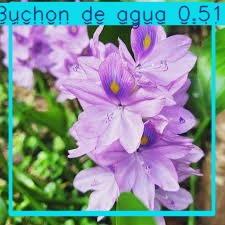

In [10]:
from ultralytics import RTDETR
from IPython.display import Image as IPImage
import random

# ── Elegir imagen ──
# Opción A (al azar): una imagen de validación cualquiera
IMAGEN = random.choice(list((RTDETR_DATA / "valid" / "images").glob("*.jpg")))
# Opción B (fija): descomenta y pon la ruta que quieras
# IMAGEN = ROOT / "Entrenamiento IyV" / "acacia_negra" / "acacia_negra_000001.jpg"
print("Imagen:", IMAGEN.name)

weights = RTDETR_RUN / "weights" / "best.pt"
assert weights.exists(), f"No existe {weights}. Entrena primero (sección 3)."
assert IMAGEN.exists(), f"No existe {IMAGEN}."

model = RTDETR(str(weights))
results = model.predict(str(IMAGEN), conf=0.3)
out = ROOT / "inferencia.jpg"
results[0].save(filename=str(out))

IPImage(str(out))

6.1


Imagen: 77c5a8849351d4ef4c8f65a63efce4d218534ae3_jpg.rf.xz6BhGQhAa0eafjEV9Hh.jpg


[2026-05-24 18:52:17] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


1 detecciones (umbral 0.3):
  Helecho de agua    0.709


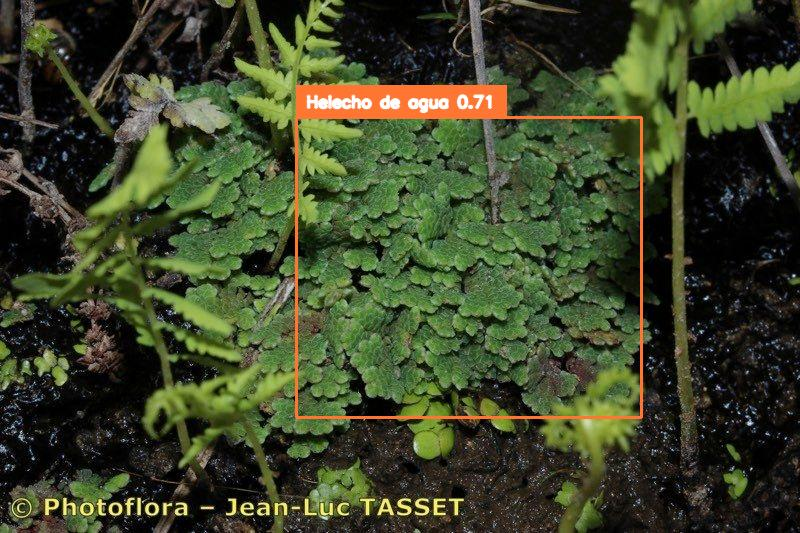

In [11]:
import json, random
import supervision as sv
from PIL import Image
from rfdetr import RFDETRBase
from IPython.display import Image as IPImage

RF_CKPT = RFDETR_RUN / "checkpoint_best_regular.pth"
assert RF_CKPT.exists(), f"No existe {RF_CKPT}. Entrena RF-DETR primero (sección 4)."

cats = json.load(open(RFDETR_DATA / "train" / "_annotations.coco.json"))["categories"]
CLASES = {c["id"]: c["name"] for c in cats}

# ── Elegir imagen ──
# Opción A (al azar): una imagen de validación cualquiera
IMAGEN = random.choice(list((RFDETR_DATA / "valid").glob("*.jpg")))
# Opción B (fija): descomenta y pon la ruta que quieras
# IMAGEN = RFDETR_DATA / "valid" / "retamo_espinoso_000001_jpg.rf.JA03rklHWKJsAZ3UFrVR.jpg"
print("Imagen:", IMAGEN.name)

UMBRAL = 0.3
model_rf = RFDETRBase(pretrain_weights=str(RF_CKPT), num_classes=5, resolution=448)

imagen = Image.open(IMAGEN).convert("RGB")
det = model_rf.predict(imagen, threshold=UMBRAL)

print(f"{len(det)} detecciones (umbral {UMBRAL}):")
for cid, conf in zip(det.class_id, det.confidence):
    print(f"  {CLASES.get(int(cid), cid):<18} {conf:.3f}")

# Anotaciones proporcionales al tamaño de la imagen (ni gruesas ni diminutas)
th = sv.calculate_optimal_line_thickness(resolution_wh=imagen.size)
ts = sv.calculate_optimal_text_scale(resolution_wh=imagen.size)
labels = [f"{CLASES.get(int(cid), cid)} {conf:.2f}"
          for cid, conf in zip(det.class_id, det.confidence)]
anotada = imagen.copy()
anotada = sv.BoxAnnotator(thickness=th).annotate(anotada, det)
anotada = sv.LabelAnnotator(text_scale=ts, text_thickness=th).annotate(anotada, det, labels)

anotada.save(str(ROOT / "inferencia_rfdetr.jpg"))
IPImage(str(ROOT / "inferencia_rfdetr.jpg"), width=600)